<a href="https://colab.research.google.com/github/Rossiwulandari/PRATIKUM_5/blob/main/PRATIKUM_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"wulandari101","key":"206048eeeb5ee136ee3875128f28398f"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d dhruvmak/font-recognition-data

Dataset URL: https://www.kaggle.com/datasets/dhruvmak/font-recognition-data
License(s): CC0-1.0
100% 1.27G/1.27G [00:07<00:00, 186MB/s]



In [5]:
!unzip -q font-recognition-data.zip

In [6]:
!ls

 drive		      'Font Dataset Large Color'   sample_data
'Font Dataset Large'   font-recognition-data.zip


In [32]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten

In [8]:
arial_path = '/content/Font Dataset Large/Arial'
brandish_path = '/content/Font Dataset Large/Brandish'
consolas_path = '/content/Font Dataset Large/Consolas'
didot_path = '/content/Font Dataset Large/Didot'

In [9]:
arial_filenames = os.listdir(arial_path)
brandish_filenames = os.listdir(brandish_path)
consolas_filenames = os.listdir(consolas_path)
didot_filenames = os.listdir(didot_path)

In [10]:
def load_image(filenames, path):
    images = []

    for filename in tqdm(filenames):
        image = cv2.imread(path + '/' + filename)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        images.append(image)

    return images

In [11]:
arial_images = load_image(arial_filenames, arial_path)
brandish_images = load_image(brandish_filenames, brandish_path)
consolas_images = load_image(consolas_filenames, consolas_path)
didot_images = load_image(didot_filenames, didot_path)

100%|██████████| 5000/5000 [00:00<00:00, 10095.15it/s]


In [12]:
heights = []
widths = []

for image in arial_images:
    height = image.shape[0]
    width = image.shape[1]

    widths.append(width)
    heights.append(height)

print('max_h: {}, min_h: {}'.format(max(heights), min(heights)))
print('max_w: {}, min_w: {}'.format(max(widths), min(widths)))

max_h: 32, min_h: 32
max_w: 248, min_w: 30


In [13]:
def take_80_pixels(images_list):
    new_images = []

    for image in images_list:
        if image.shape[1] >= 80:
            new_images.append(image[:, :80])
        else:
            pass

    return np.array(new_images)

In [14]:
arial_80 = take_80_pixels(arial_images)
brandish_80 = take_80_pixels(brandish_images)
consolas_80 = take_80_pixels(consolas_images)
didot_80 = take_80_pixels(didot_images)

In [15]:
print(arial_80.shape)
print(brandish_80.shape)
print(consolas_80.shape)
print(didot_80.shape)

(4079, 32, 80)
(4028, 32, 80)
(4741, 32, 80)
(3920, 32, 80)


In [16]:
all_images = np.append(arial_80, brandish_80, axis=0)
all_images = np.append(all_images, consolas_80, axis=0)
all_images = np.append(all_images, didot_80, axis=0)

all_images.shape

(16768, 32, 80)

In [17]:
all_images = all_images.reshape(
    all_images.shape[0],
    all_images.shape[1],
    all_images.shape[2],
    1
)

all_images.shape

(16768, 32, 80, 1)

In [18]:
labels = (
    [0] * len(arial_80) +
    [1] * len(brandish_80) +
    [2] * len(consolas_80) +
    [3] * len(didot_80)
)

len(labels)

16768

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    all_images,
    labels,
    test_size=0.3,
    random_state=88
)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [21]:
y_train = y_train[:, np.newaxis]
y_test = y_test[:, np.newaxis]

In [23]:
encoder = OneHotEncoder()

y_train_encoded = encoder.fit_transform(y_train).toarray()
y_test_encoded = encoder.transform(y_test).toarray()

In [24]:
print(y_train[:5])
print(y_train_encoded[:5])

[[1]
 [3]
 [0]
 [3]
 [3]]
[[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [25]:
input_shape = (
    all_images.shape[1],
    all_images.shape[2],
    1
)

In [26]:
model = Sequential()

model.add(
    Conv2D(
        32,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        input_shape=input_shape
    )
)

model.add(
    Conv2D(
        64,
        kernel_size=(3, 3),
        activation='relu'
    )
)

model.add(MaxPool2D(2, 2))

model.add(Flatten())

model.add(Dense(100, activation='relu'))
model.add(Dense(50, activation='relu'))

model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,744,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,768,170 (14.37 MB)

 Trainable params: 3,768,170 (14.37 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc']
)

In [29]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

predictions

158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step


array([0, 0, 0, ..., 0, 0, 0])

In [30]:
y_test = y_test.reshape(y_test.shape[0])

In [34]:
import seaborn as sns

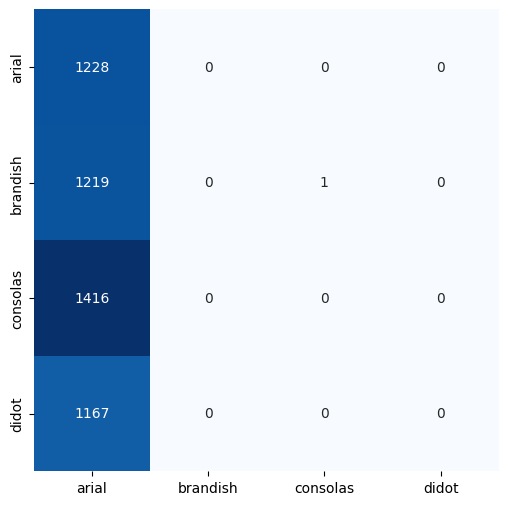

In [35]:
cm = confusion_matrix(y_test, predictions)

label_names = ['arial', 'brandish', 'consolas', 'didot']

plt.figure(figsize=(6, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
    cmap=plt.cm.Blues
)

plt.show()

In [36]:
misses = []

for i in range(len(predictions)):
    if y_test[i] != predictions[i]:
        misses.append(i)

print(misses)

[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 16, 19, 20, 21, 22, 24, 25, 26, 28, 30, 31, 32, 34, 35, 36, 37, 38, 41, 42, 44, 45, 47, 49, 50, 51, 53, 54, 55, 56, 58, 60, 61, 62, 63, 65, 66, 67, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 91, 92, 94, 95, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 110, 111, 113, 116, 117, 118, 120, 121, 123, 124, 126, 127, 128, 130, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 147, 148, 149, 151, 152, 153, 154, 156, 158, 159, 161, 162, 163, 164, 165, 166, 167, 169, 170, 171, 172, 174, 177, 179, 181, 183, 184, 186, 187, 188, 189, 190, 191, 193, 195, 197, 198, 200, 201, 203, 204, 205, 206, 207, 208, 210, 211, 212, 213, 214, 215, 216, 219, 220, 221, 222, 224, 225, 226, 227, 229, 230, 232, 234, 235, 236, 237, 238, 241, 242, 244, 246, 249, 250, 251, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 270, 271, 272, 273, 274, 275, 276, 277, 280, 281, 282, 283, 284, 285, 286

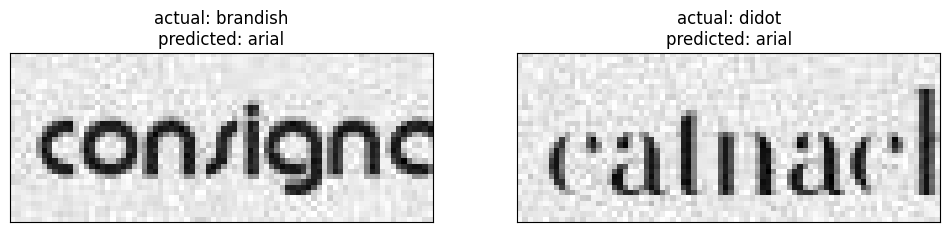

In [37]:
fig, axes = plt.subplots(
    ncols=2,
    sharex=False,
    figsize=(12, 3)
)

for i, miss in zip(range(2), misses):

    axes[i].set_title(
        'actual: {}\npredicted: {}'.format(
            str(label_names[y_test[miss]]),
            str(label_names[predictions[miss]])
        )
    )

    axes[i].imshow(X_test[miss], cmap='gray')

    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)

plt.show()